In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from input_pipeline import preprocess_dataset, batch_sampler
import baselines
from model import SpectraFormer
import xarray as xr
import jax
import flax.linen as nn
import optax

### Dataset loading

In [37]:
train_ds = preprocess_dataset(xr.load_dataarray('../data/SiC_19x10x3.nc'))
test_ds = preprocess_dataset(xr.load_dataarray('../data/SiC+Graphene_50x20.nc'))

dummy_example = next(batch_sampler(train_ds, batch_size=1))
print("Data batch shapes:")
for k, v in dummy_example.items():
    print(f"  {k} -> {v.shape}")

Data batch shapes:
  spectra -> (1, 1015, 1)
  masked_spectra -> (1, 1015, 1)
  wave_number -> (1015, 1)
  mask -> (1015,)


### Model loading

In [38]:
from inference import predict, plot_results
import orbax.checkpoint as ocp
checkpointer = ocp.StandardCheckpointer()
ckpt_dir = "gs://spectraformer/checkpoints/"
test_batch = next(batch_sampler(test_ds, batch_size=1))

In [39]:
median_baseline_variables = checkpointer.restore(ckpt_dir + 'baselines:median/100x10/')
baseline_predictions = predict(baselines.median, median_baseline_variables, test_batch)
for k, v in baseline_predictions.items():
    print(f"  {k} -> {v.shape}")

  spectra -> (1015,)
  masked_spectra -> (1015,)
  wave_number -> (1015,)
  mask -> (1015,)
  predicted_spectra -> (1015,)
  predicted_difference -> (1015,)


Text(0.5, 1.0, 'Median Baseline')

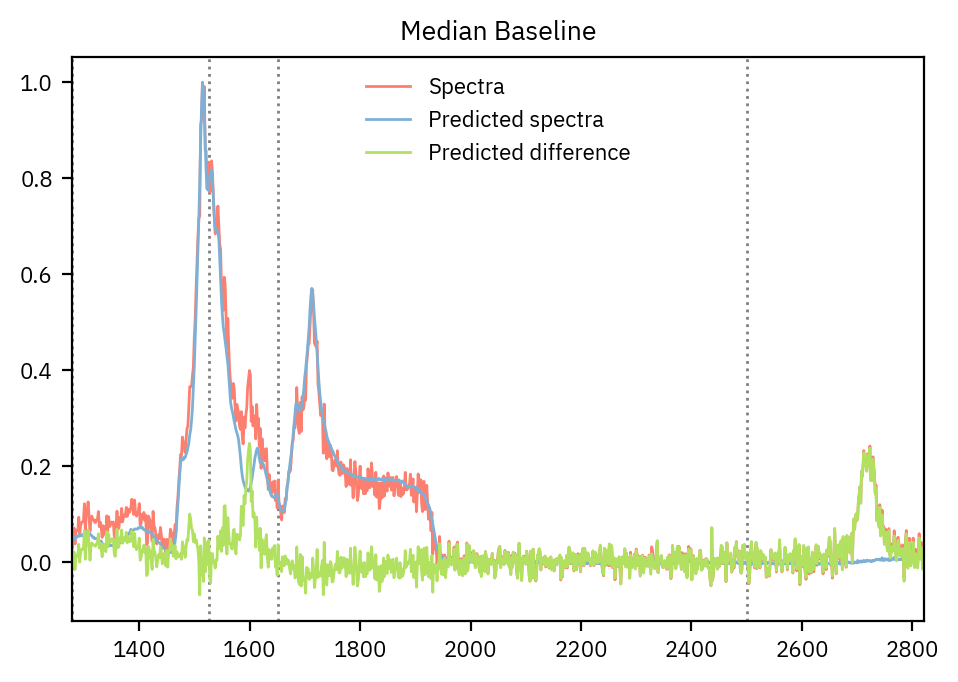

In [43]:
fig, ax = plot_results(baseline_predictions)
ax.set_title('Median Baseline')

In [8]:
ckpt_manager = ocp.CheckpointManager(
        ckpt_dir + 'spectraformer:base',
        item_handlers=ocp.StandardCheckpointHandler(),
    )


In [13]:
import ml_confs
from flax.training.train_state import TrainState
configs = ml_confs.from_dict(ckpt_manager.metadata())

# Re-initialize model based on loaded configs
model = SpectraFormer(
    num_heads=configs.num_heads,
    num_layers=configs.num_layers,
    embedding_dim=configs.embedding_dim,
)

# RNG Keys
root_key = jax.random.key(seed=configs.root_rng_seed)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)

# Model Initialization
variables = model.init(
    params_key,
    dummy_example["masked_spectra"][0],
    dummy_example["wave_number"],
    dummy_example["mask"],
    training=False,
)

state = TrainState.create(
    apply_fn=jax.jit(
        model.apply, static_argnames=("training", "capture_intermediates")
    ),
    params=variables["params"],
    tx=optax.adam(configs.learning_rate),
)
# Restore checkpoint
state = ckpt_manager.restore(
    ckpt_manager.latest_step(), args=ocp.args.StandardRestore(state)
)

In [15]:
tabulate_fn = nn.tabulate(model, jax.random.key(0), depth = 1, console_kwargs={'force_jupyter': True})
print(tabulate_fn(dummy_example['masked_spectra'][0], dummy_example['wave_number'], dummy_example['mask'], training = False))

                                               SpectraFormer Summary                                               
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ path                  ┃ module                ┃ inputs                ┃ outputs          ┃ params               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│                       │ SpectraFormer         │ - float32[1015,1]     │ float32[1015,1]  │                      │
│                       │                       │ - float32[1015,1]     │                  │                      │
│                       │                       │ - bool[1015]          │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LinearProjection_0    │ LinearProjection      │ float32[1015,1]       │ float32[1015,32] │ 64 (256 B)           │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LinearProjection_1    │ LinearProjection      │ float32[1015,1]       │ float32[1015,32] │ 64 (256 B)           │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 14,816 (59.3 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 14,816 (59.3 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 14,816 (59.3 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 14,816 (59.3 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LayerNorm_0           │ LayerNorm             │ float32[1015,32]      │ float32[1015,32] │ bias: float32[32]    │
│                       │                       │       

In [16]:
spectraformer_predictions = predict(state.apply_fn, {'params': state.params}, test_batch, test_batch['mask'])
for k, v in spectraformer_predictions.items():
    print(f"  {k} -> {v.shape}")

  spectra -> (1015,)
  masked_spectra -> (1015,)
  wave_number -> (1015,)
  mask -> (1015,)
  predicted_spectra -> (1015,)
  predicted_difference -> (1015,)


Text(0.5, 1.0, 'Spectraformer Baseline')

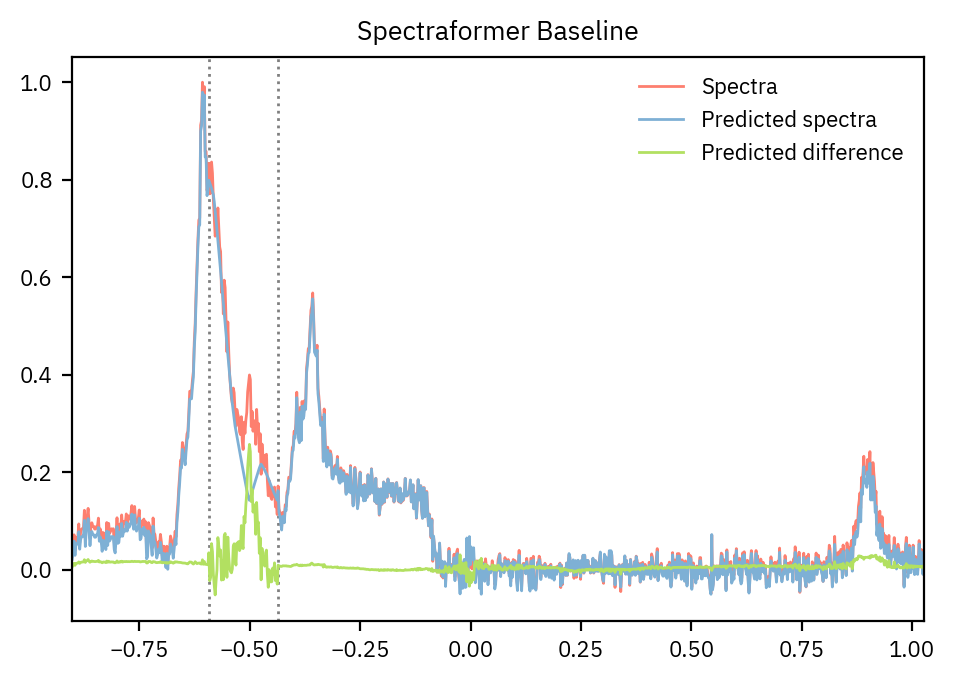

In [17]:
fig, ax = plot_results(spectraformer_predictions)
ax.set_title('Spectraformer Baseline')